In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import random

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Functions

In [4]:
def eval(model, test_dataloader, loss_fn, showProgress = False):
    model.eval()
    correct = 0
    total = 0
    cum_loss = 0.0

    if showProgress:
        bar = tqdm(test_dataloader)
    else:
        bar = test_dataloader

    with torch.no_grad():
        for inp, label in bar:
            inp, label = inp.to(device), label.to(device)
            outputs = model(inp)
            cum_loss += loss_fn(outputs, label).item() * inp.size(0)
            
            _, predicted = torch.max(outputs, 1)    # returns maxValue, Index of the maximum logit value
            
            total += label.size(0)
            correct += (predicted == label).sum().item()

    epoch_test_acc = correct / total
    epoch_test_loss = cum_loss / total

    return epoch_test_acc, epoch_test_loss

def train_model(model, optimizer, loss_fn, train_dataloader, num_epochs, test_per_epoch = False, test_dataloader = None):
    train_loss_list = []
    train_acc_list = []
    test_acc_list = []
    test_loss_list = []
    
    for epoch in range(num_epochs):

        model.train()

        cum_loss = 0.0
        correct = 0
        total = 0

        # Bar Visualizer
        bar = tqdm(train_dataloader)

        for inp, label in bar:
            inp, label = inp.to(device), label.to(device)

            optimizer.zero_grad()

            outputs = model(inp)
            _, predicted = torch.max(outputs, 1)
            loss = loss_fn(outputs, label)

            loss.backward()
            optimizer.step()

            cum_loss += loss.item() * inp.size(0)
            correct += (predicted == label).sum().item()
            total += label.size(0)

        epoch_loss = cum_loss / total
        train_loss_list.append(epoch_loss)
        epoch_acc = correct / total
        train_acc_list.append(epoch_acc)

        if test_per_epoch:
            test_acc, test_loss = eval(model, test_dataloader, loss_fn)
            test_acc_list.append(test_acc)
            test_loss_list.append(test_loss)
            print(f"""Epoch: {epoch + 1}/{num_epochs} | Train Loss: {epoch_loss:.3f} | Train Acc: {epoch_acc:.3f} | Test Acc: {test_acc:.3f}""")
        else:
            print(f"""Epoch: {epoch + 1}/{num_epochs} | Train Loss: {epoch_loss:.3f} | Train Acc: {epoch_acc:.3f}""")

    return model, train_loss_list, train_acc_list, test_acc_list, test_loss_list

def getFeatureMaps(image, model, layers = None):
    feat_map = {}
    def get_activation(name):
        def hook(model, input, output):
            feat_map[name] = output.detach()
        return hook
    
    hooks = []
    for name, module in model.named_modules():
        if layers is None or (layers is not None and name in layers):
            hooks.append(module.register_forward_hook(get_activation(name)))
    
    
    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))

    for h in hooks: 
        h.remove()
    return feat_map

def showFeatMaps(feat_map, title, max_maps = None, figsize = (10, 10)):
    if max_maps is not None and max_maps % 2 != 0:
        print("Maximum number of maps must be even")
        return
    
    for layer, map in feat_map.items():
        map = map.cpu().numpy()

        if map.ndim == 4:
            map = map[0]

        if max_maps is None:
            num_maps = map.shape[0]
        else:
            num_maps = min(map.shape[0], max_maps)
        row = int(num_maps ** 0.5)

        fig, axes = plt.subplots(row, row, figsize = figsize)
        fig.suptitle(f"{title}_{layer}")

        for i, ax in enumerate(axes.flat):
            ax.imshow(map[i], cmap = 'gray')
            ax.axis('off')
        plt.show()

# Main

In [5]:
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 60

In [6]:
data_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

In [7]:
train_data = datasets.ImageFolder("./Data/Sketch_data/train/", data_transforms)
test_data = datasets.ImageFolder("./Data/Sketch_data/test/", data_transforms)
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, persistent_workers=True, pin_memory=True)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, persistent_workers=True, pin_memory=True)

In [8]:
train_data_size = len(train_data)
test_data_size = len(test_data)
classes = train_data.classes
num_classes = len(classes)
print('Number of Classes in Training Data: ', num_classes)
print('Number of Images in Training Data: ', train_data_size)

Number of Classes in Training Data:  99
Number of Images in Training Data:  3465


In [9]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_feat = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_feat, num_classes)
model_ft = model_ft.to(device)

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_ft.parameters(), lr=LEARNING_RATE)

In [11]:
model_ft, train_loss_list, train_acc_list, test_acc_list, test_loss_list = train_model(model_ft, optimizer, loss_fn, train_dataloader, NUM_EPOCHS, True, test_dataloader)

100%|██████████| 109/109 [00:44<00:00,  2.45it/s]


Epoch: 1/60 | Train Loss: 4.708 | Train Acc: 0.024 | Test Acc: 0.022


100%|██████████| 109/109 [00:26<00:00,  4.18it/s]


Epoch: 2/60 | Train Loss: 4.528 | Train Acc: 0.037 | Test Acc: 0.040


100%|██████████| 109/109 [00:24<00:00,  4.49it/s]


...

Epoch: 58/60 | Train Loss: 0.820 | Train Acc: 0.910 | Test Acc: 0.724


100%|██████████| 109/109 [00:22<00:00,  4.81it/s]


Epoch: 59/60 | Train Loss: 0.800 | Train Acc: 0.910 | Test Acc: 0.730


100%|██████████| 109/109 [00:22<00:00,  4.79it/s]


Epoch: 60/60 | Train Loss: 0.777 | Train Acc: 0.919 | Test Acc: 0.732


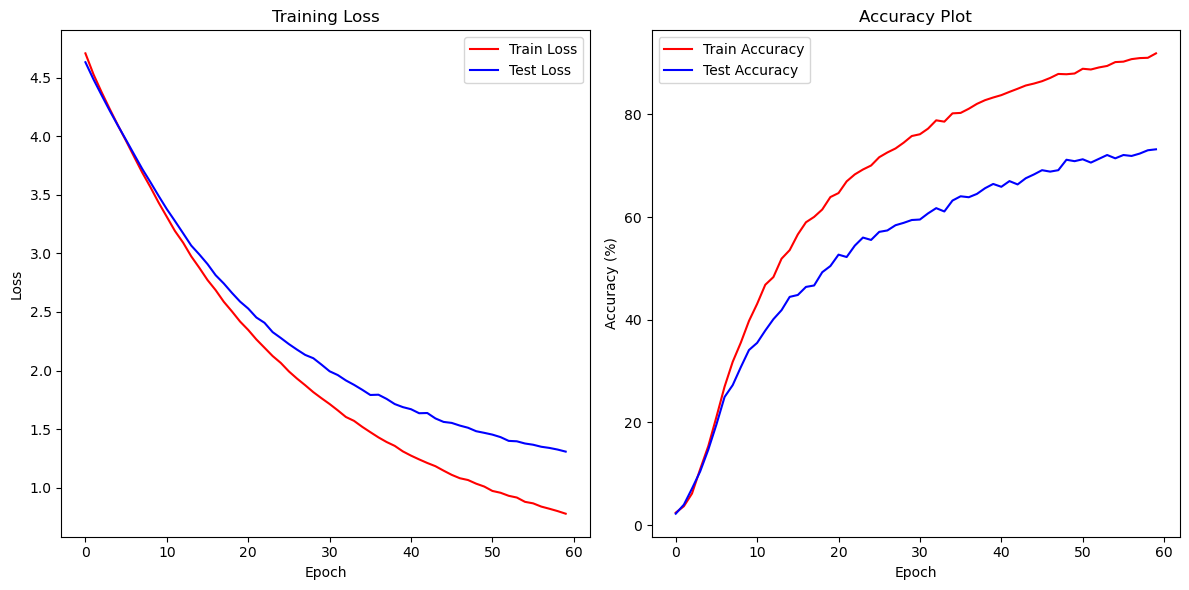

In [12]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize = (12, 6))
axes[0].plot(train_loss_list, color = 'red', label = 'Train Loss')
axes[0].plot(test_loss_list, color = 'blue', label = 'Test Loss')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot([x * 100 for x in train_acc_list], color = 'red', label = 'Train Accuracy')
axes[1].plot([x * 100 for x in test_acc_list], color = 'blue', label = 'Test Accuracy')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Plot")
axes[1].legend()
plt.tight_layout()
plt.show()

#### Visualize the Feature Maps

In [13]:
test_img, label = train_data[random.randint(0,3464)]
layers_to_hook = ['layer1', 'layer2', 'layer4']
model_vanilla = models.resnet18(weights='IMAGENET1K_V1').to(device)

In [14]:
vanilla_featMap = getFeatureMaps(test_img, model_vanilla, layers_to_hook)
FT_featMap = getFeatureMaps(test_img, model_ft, layers_to_hook)

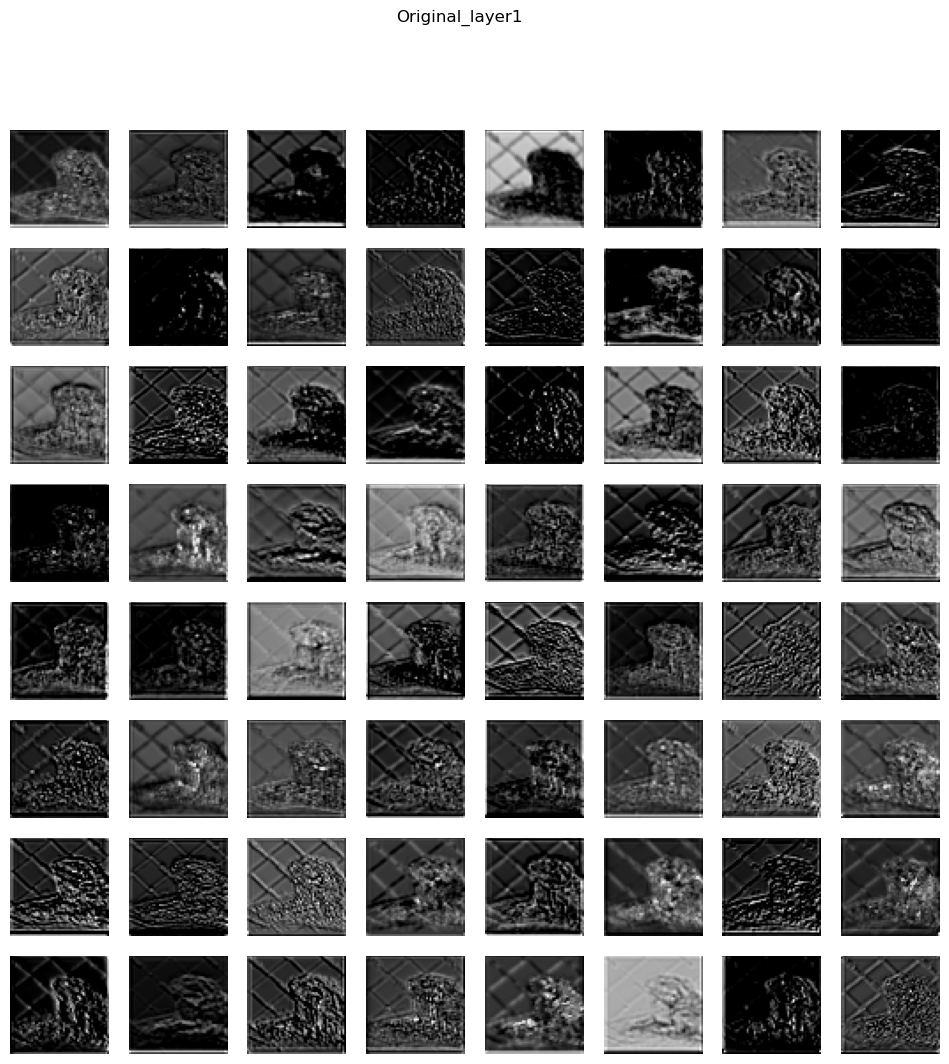

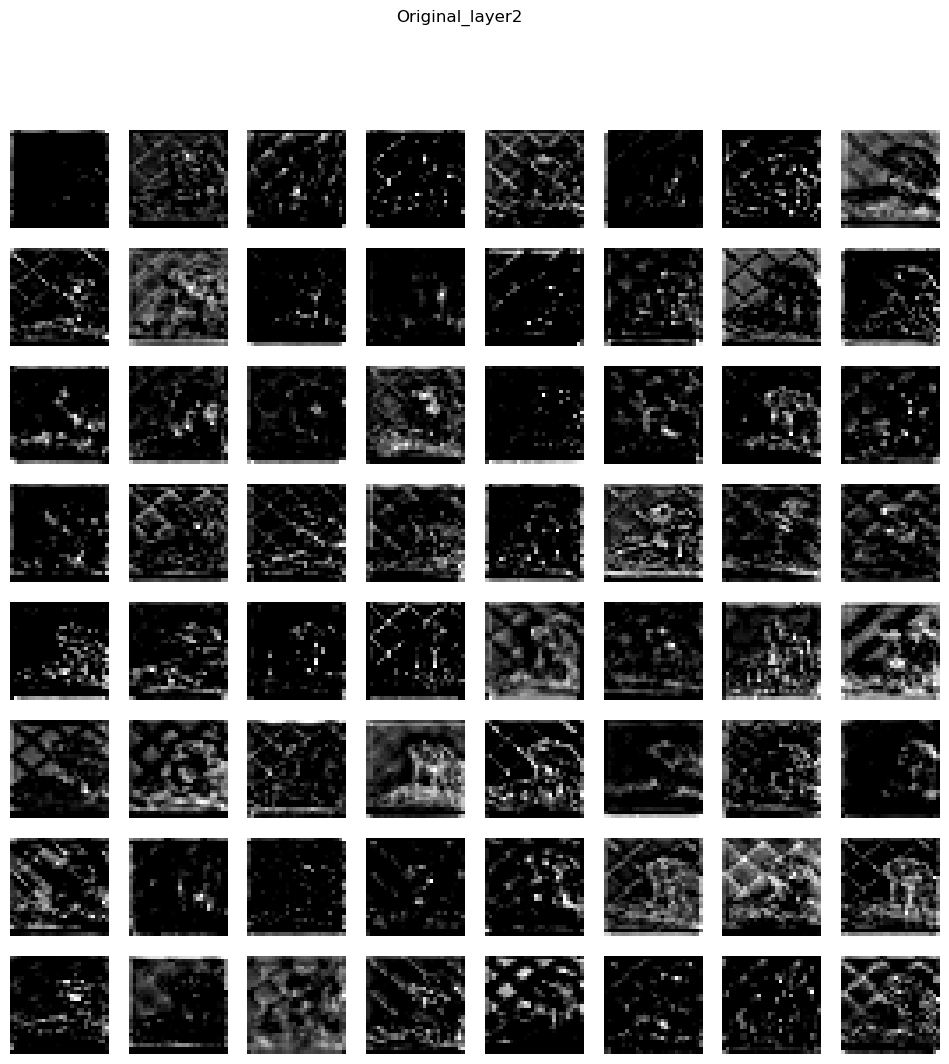

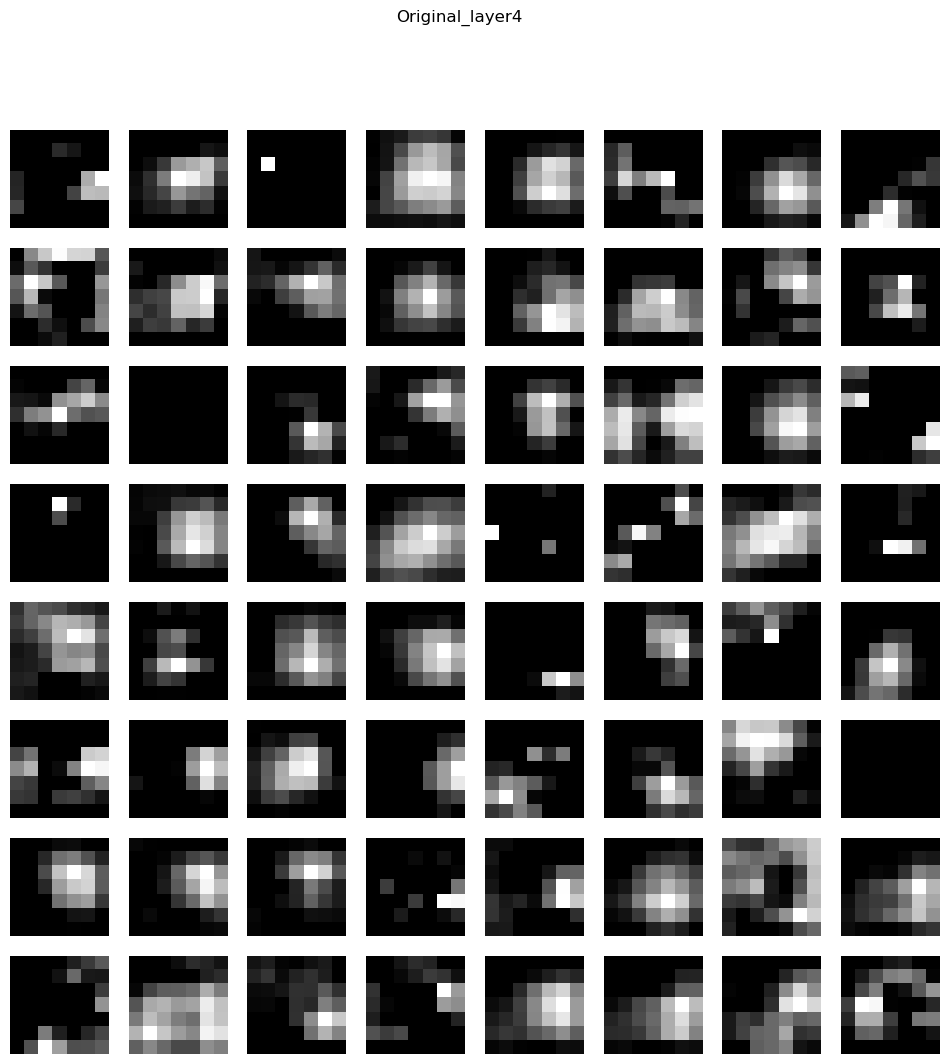

In [15]:
showFeatMaps(vanilla_featMap, "Original", max_maps=64, figsize=(12, 12))

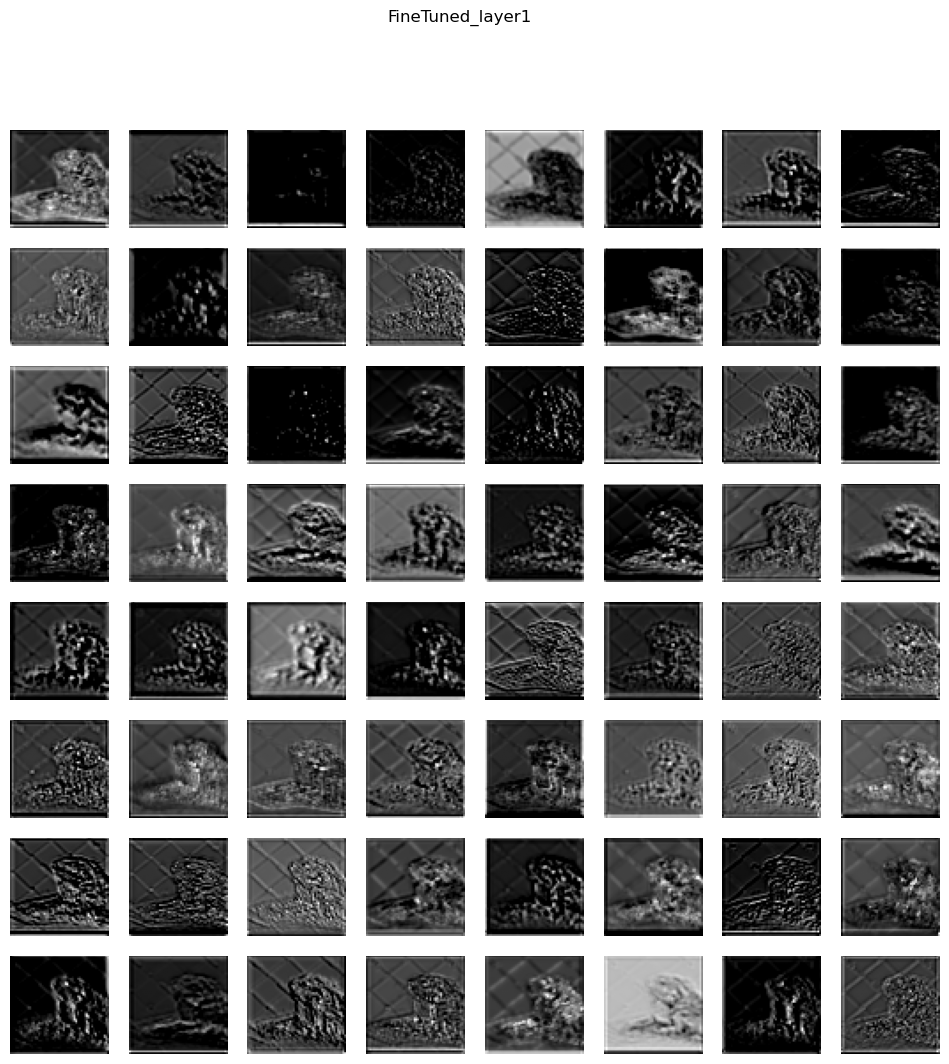

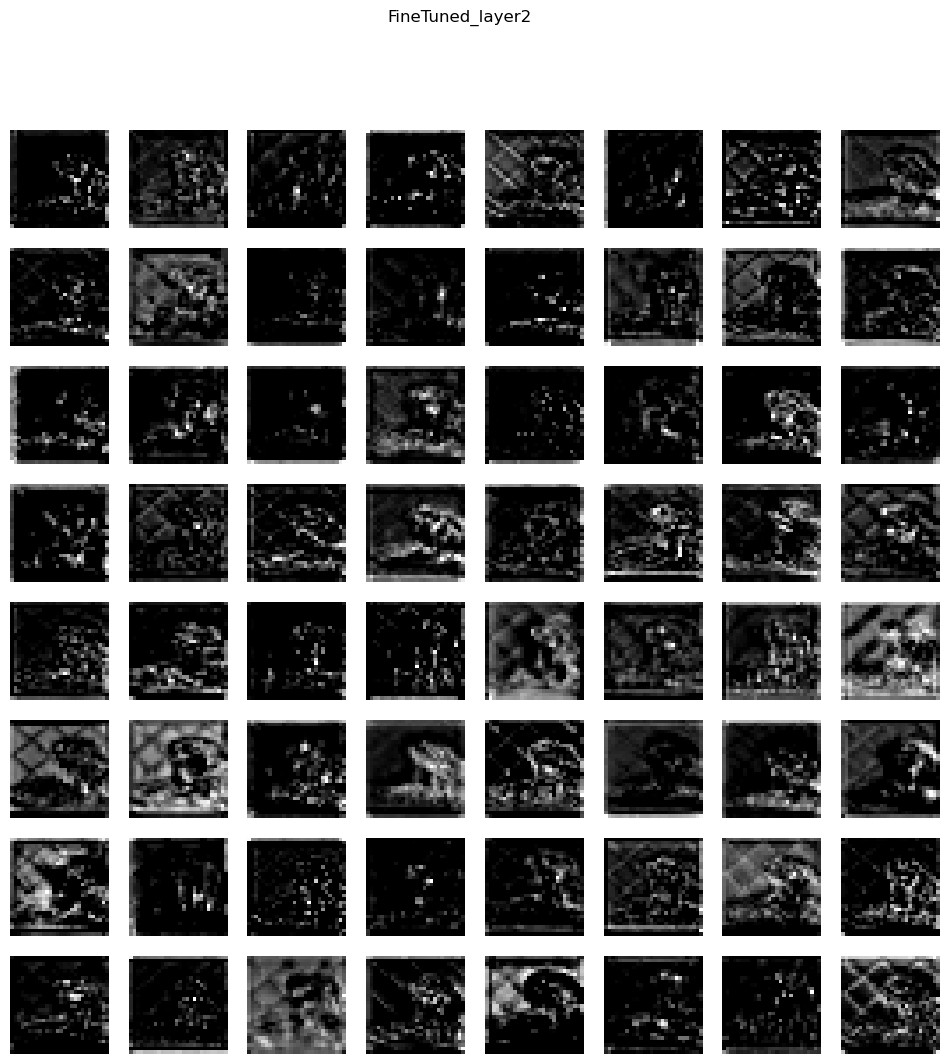

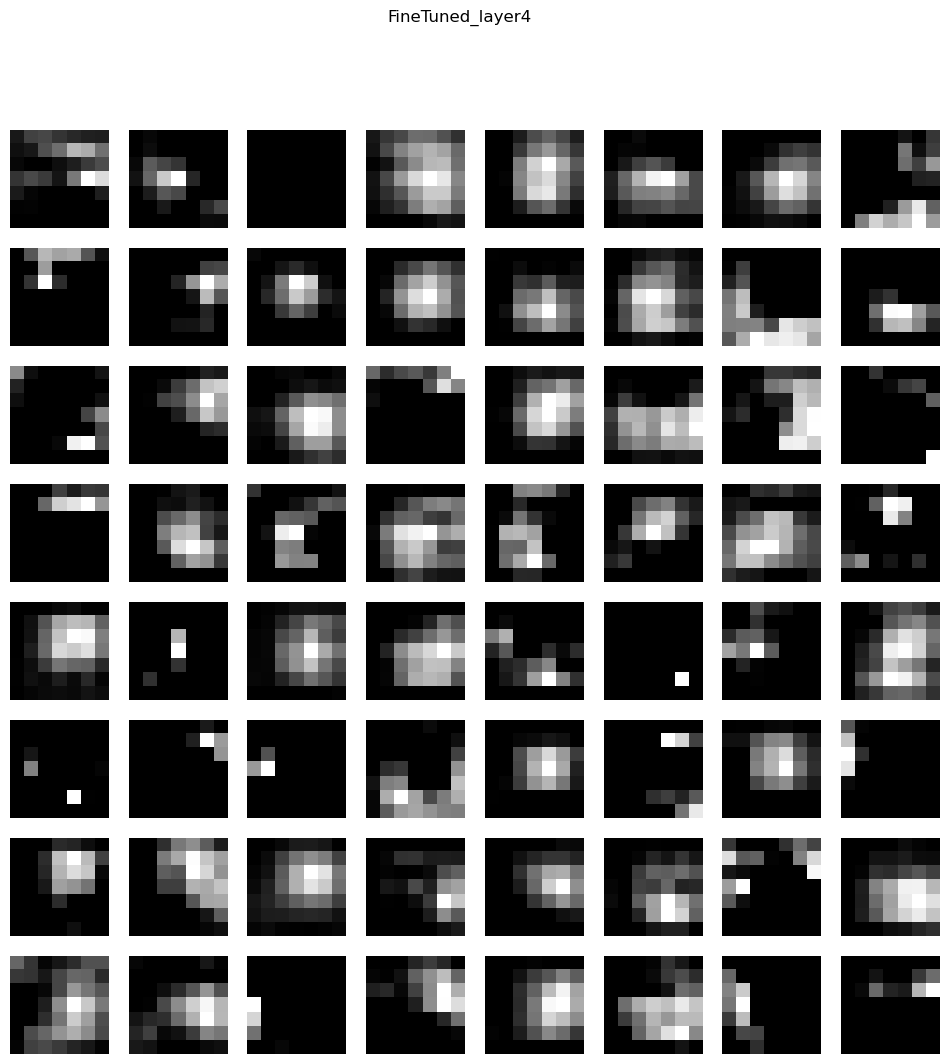

In [16]:
showFeatMaps(FT_featMap, "FineTuned", max_maps=64, figsize=(12, 12))

### Update BatchNorm Layers only

In [17]:
model_batchnorm = models.resnet18(weights='IMAGENET1K_V1')

In [31]:
for module in model_batchnorm.modules():
    for param in module.parameters():
        if isinstance(module, nn.BatchNorm2d):
            param.requires_grad = True
        else:
            param.requires_grad = False

In [19]:
num_feat = model_batchnorm.fc.in_features
model_batchnorm.fc = nn.Linear(num_feat, num_classes)
model_batchnorm = model_batchnorm.to(device)

In [20]:
update_param = []
for param in model_batchnorm.parameters():
    if param.requires_grad:
        update_param.append(param)
        
optimizer_batchnorm = optim.SGD(update_param, lr=LEARNING_RATE)

In [21]:
model_batchnorm, BN_train_loss_list, BN_train_acc_list, BN_test_acc_list, BN_test_loss_list = train_model(model_batchnorm, optimizer_batchnorm, loss_fn, train_dataloader, num_epochs=NUM_EPOCHS, test_per_epoch=True, test_dataloader=test_dataloader)

100%|██████████| 109/109 [00:17<00:00,  6.17it/s]


Epoch: 1/60 | Train Loss: 4.807 | Train Acc: 0.010 | Test Acc: 0.009


100%|██████████| 109/109 [00:16<00:00,  6.46it/s]


Epoch: 2/60 | Train Loss: 4.687 | Train Acc: 0.016 | Test Acc: 0.015


100%|██████████| 109/109 [00:16<00:00,  6.42it/s]


...

Epoch: 58/60 | Train Loss: 1.936 | Train Acc: 0.667 | Test Acc: 0.604


100%|██████████| 109/109 [00:16<00:00,  6.78it/s]


Epoch: 59/60 | Train Loss: 1.923 | Train Acc: 0.664 | Test Acc: 0.615


100%|██████████| 109/109 [00:16<00:00,  6.60it/s]


Epoch: 60/60 | Train Loss: 1.884 | Train Acc: 0.681 | Test Acc: 0.599


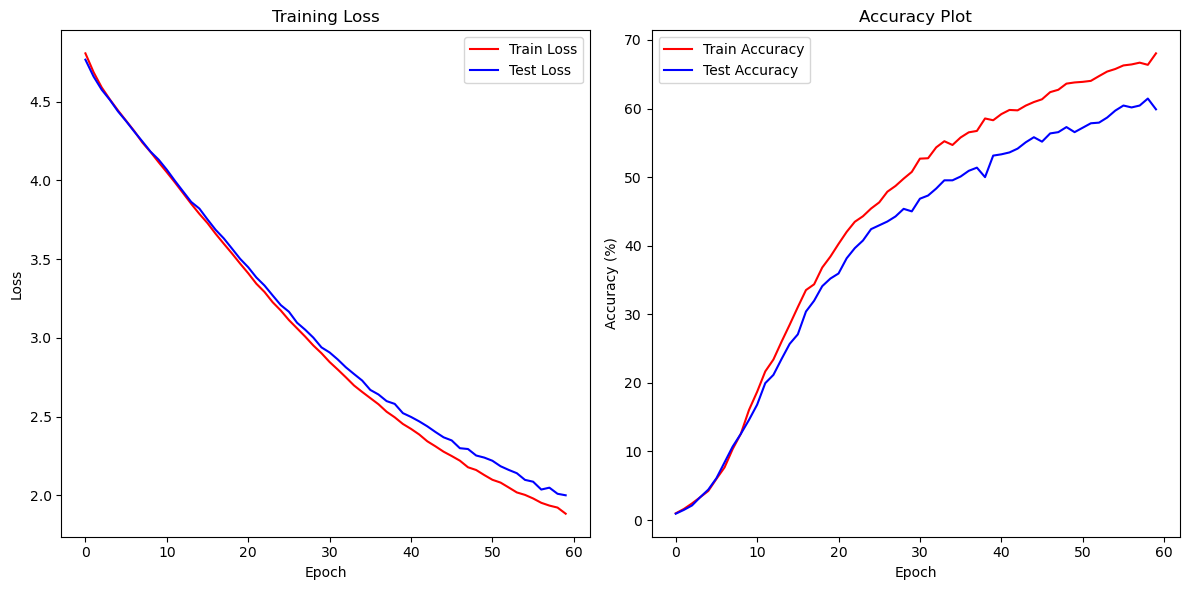

In [22]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize = (12, 6))
axes[0].plot(BN_train_loss_list, color = 'red', label = 'Train Loss')
axes[0].plot(BN_test_loss_list, color = 'blue', label = 'Test Loss')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot([x * 100 for x in BN_train_acc_list], color = 'red', label = 'Train Accuracy')
axes[1].plot([x * 100 for x in BN_test_acc_list], color = 'blue', label = 'Test Accuracy')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Plot")
axes[1].legend()
plt.tight_layout()
plt.show()